# Density NN Shootout — Runtime vs Accuracy

This notebook benchmarks several **real-time friendly** density architectures on **real Minecraft density data**.

## Goal
Find an architecture that:
- converges extremely well given enough training time
- is **extremely fast at runtime**
- preserves solid/air sign accuracy

## Strategy
We compare a small set of candidates spanning the likely Pareto frontier:

| ID | Candidate | Runtime bias | Accuracy bias | Hypothesis |
|---|---|---:|---:|---|
| MLP | Per-voxel 1x1x1 MLP | Excellent | Weak | Fast lower bound; no spatial mixing |
| SEP | Depthwise-separable residual 3D net | Excellent | Good | Strong runtime/accuracy tradeoff |
| AXIAL | Axial residual mixer | Very good | Very good | Cheap larger receptive field |
| UNET | Tiny anisotropic U-Net | Fair | Best | Likely teacher / upper-bound candidate |

The notebook tracks both **regression quality** and **deployment-relevant latency**.

In [16]:
from __future__ import annotations

import copy
import json
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    import pandas as pd
except ImportError:
    pd = None

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CPU_DEVICE = torch.device('cpu')
print('DEVICE =', DEVICE)
print('Torch =', torch.__version__)

DEVICE = cpu
Torch = 2.10.0+cpu


## Load Real Density Data

This notebook intentionally fails if the real NPZ is missing. No synthetic fallback.

In [ ]:
def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'noise_training_data' / 'stage1_density_data.npz').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root containing noise_training_data/stage1_density_data.npz')

REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / 'noise_training_data' / 'stage1_density_data.npz'
ARTIFACT_DIR = REPO_ROOT / 'VoxelTree' / 'notebooks' / 'experimental' / 'artifacts' / 'density_nn_shootout'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

data = np.load(DATA_PATH)
inputs = data['inputs'].astype(np.float32)
targets = data['outputs'].astype(np.float32)

INPUT_CH = inputs.shape[-1]
OUTPUT_CH = targets.shape[-1]
N = inputs.shape[0]

print('REPO_ROOT =', REPO_ROOT)
print('DATA_PATH =', DATA_PATH)
print('inputs  =', inputs.shape)
print('targets =', targets.shape)
print('solid fraction =', float((targets > 0).mean()))

REPO_ROOT = c:\Users\JeffHall\git\MC
DATA_PATH = c:\Users\JeffHall\git\MC\noise_training_data\phase_1a_data.npz
inputs  = (81, 4, 48, 4, 7)
targets = (81, 4, 48, 4, 1)
solid fraction = 0.31933191872427985


In [18]:
# Train/val/test split on chunks
perm = np.random.default_rng(SEED).permutation(N)
n_train = max(1, int(0.70 * N))
n_val = max(1, int(0.15 * N))
train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]
if len(test_idx) == 0:
    test_idx = val_idx

X_train = torch.from_numpy(inputs[train_idx]).permute(0, 4, 1, 2, 3).contiguous()
Y_train = torch.from_numpy(targets[train_idx]).permute(0, 4, 1, 2, 3).contiguous()
X_val = torch.from_numpy(inputs[val_idx]).permute(0, 4, 1, 2, 3).contiguous()
Y_val = torch.from_numpy(targets[val_idx]).permute(0, 4, 1, 2, 3).contiguous()
X_test = torch.from_numpy(inputs[test_idx]).permute(0, 4, 1, 2, 3).contiguous()
Y_test = torch.from_numpy(targets[test_idx]).permute(0, 4, 1, 2, 3).contiguous()

BATCH_SIZE = 8
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f'train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}')
print('example batch X:', tuple(next(iter(train_loader))[0].shape))

train=56  val=12  test=13
example batch X: (8, 7, 4, 48, 4)


## Shootout Configuration

The default settings are a **reasonable smoke-test**.
For serious convergence studies, increase `EPOCHS` aggressively (for example 100–400+).

Because runtime is the real constraint, the notebook records:
- validation and test MSE
- sign accuracy (`density > 0` = solid)
- boundary sign accuracy near the decision surface
- CPU latency for single-chunk inference
- optional active-device latency
- parameter count

In [19]:
EPOCHS = 120             # long run for grokking / near-perfect convergence
LR = 2e-3
WEIGHT_DECAY = 1e-5
SIGN_LOSS_WEIGHT = 0.20
BOUNDARY_EPS = 0.05
LATENCY_WARMUP = 20
LATENCY_RUNS = 200
RUN_ACTIVE_DEVICE_BENCH = torch.cuda.is_available()
ACTIVE_CANDIDATES = ['axial', 'unet']  # focus on the two strongest candidates

print('EPOCHS =', EPOCHS)
print('ACTIVE_CANDIDATES =', ACTIVE_CANDIDATES)

EPOCHS = 120
ACTIVE_CANDIDATES = ['axial', 'unet']


## Metrics and Benchmark Helpers

In [20]:
def density_loss(pred: torch.Tensor, target: torch.Tensor, sign_weight: float = SIGN_LOSS_WEIGHT):
    mse = F.mse_loss(pred, target)
    sign_target = (target > 0).float()
    sign_logits = pred * 8.0
    sign = F.binary_cross_entropy_with_logits(sign_logits, sign_target)
    total = mse + sign_weight * sign
    return total, {'mse': float(mse.detach()), 'sign': float(sign.detach())}


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device) -> dict:
    model.eval()
    sum_mse = 0.0
    sum_mae = 0.0
    sum_sign = 0.0
    sum_boundary = 0.0
    sum_boundary_count = 0.0
    batches = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        sum_mse += F.mse_loss(pred, yb).item()
        sum_mae += F.l1_loss(pred, yb).item()
        sum_sign += ((pred > 0) == (yb > 0)).float().mean().item()
        boundary_mask = (yb.abs() <= BOUNDARY_EPS).float()
        if boundary_mask.sum().item() > 0:
            correct = (((pred > 0) == (yb > 0)).float() * boundary_mask).sum().item()
            sum_boundary += correct
            sum_boundary_count += boundary_mask.sum().item()
        batches += 1
    return {
        'mse': sum_mse / max(batches, 1),
        'mae': sum_mae / max(batches, 1),
        'sign_acc': sum_sign / max(batches, 1),
        'boundary_sign_acc': (sum_boundary / sum_boundary_count) if sum_boundary_count else float('nan'),
    }


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def benchmark_latency_ms(model: nn.Module, sample: torch.Tensor, device: torch.device, warmup: int = LATENCY_WARMUP, runs: int = LATENCY_RUNS) -> dict:
    model = copy.deepcopy(model).to(device).eval()
    x = sample.to(device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    for _ in range(warmup):
        _ = model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        _ = model(x)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000.0)

    arr = np.array(times, dtype=np.float64)
    return {
        'median_ms': float(np.median(arr)),
        'p90_ms': float(np.percentile(arr, 90)),
        'chunks_per_s': float(1000.0 / max(np.median(arr), 1e-9)),
    }

## Candidate Architectures

These are intentionally chosen to expose runtime / accuracy tradeoffs instead of chasing only one metric.

In [21]:
class VoxelMLP(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, width: int = 96, depth: int = 6):
        super().__init__()
        layers = [nn.Conv3d(in_ch, width, 1), nn.GELU()]
        for _ in range(depth - 2):
            layers += [nn.Conv3d(width, width, 1), nn.GELU()]
        layers += [nn.Conv3d(width, out_ch, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


class SepResBlock(nn.Module):
    def __init__(self, ch: int, expansion: int = 2):
        super().__init__()
        hidden = ch * expansion
        self.net = nn.Sequential(
            nn.Conv3d(ch, hidden, 1, bias=False),
            nn.BatchNorm3d(hidden),
            nn.GELU(),
            nn.Conv3d(hidden, hidden, 3, padding=1, groups=hidden, bias=False),
            nn.BatchNorm3d(hidden),
            nn.GELU(),
            nn.Conv3d(hidden, ch, 1, bias=False),
            nn.BatchNorm3d(ch),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.net(x))


class SeparableResNet3D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, width: int = 32, blocks: int = 6):
        super().__init__()
        body = [nn.Conv3d(in_ch, width, 1), nn.GELU()]
        for _ in range(blocks):
            body.append(SepResBlock(width))
        body.append(nn.Conv3d(width, out_ch, 1))
        self.net = nn.Sequential(*body)
    def forward(self, x):
        return self.net(x)


class AxialResBlock(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(ch, ch, kernel_size=(3, 1, 1), padding=(1, 0, 0), bias=False),
            nn.BatchNorm3d(ch),
            nn.GELU(),
            nn.Conv3d(ch, ch, kernel_size=(1, 3, 1), padding=(0, 1, 0), bias=False),
            nn.BatchNorm3d(ch),
            nn.GELU(),
            nn.Conv3d(ch, ch, kernel_size=(1, 1, 3), padding=(0, 0, 1), bias=False),
            nn.BatchNorm3d(ch),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.net(x))


class AxialMixer3D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, width: int = 32, blocks: int = 6):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv3d(in_ch, width, 1), nn.GELU())
        self.blocks = nn.Sequential(*[AxialResBlock(width) for _ in range(blocks)])
        self.head = nn.Conv3d(width, out_ch, 1)
    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x)


class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
        )
    def forward(self, x):
        return self.net(x)


class TinyUNet3D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, base: int = 24):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.down1 = nn.MaxPool3d((2, 2, 2))
        self.enc2 = DoubleConv(base, base * 2)
        self.down2 = nn.MaxPool3d((1, 2, 1))
        self.bottleneck = DoubleConv(base * 2, base * 4)
        self.up2 = nn.Upsample(scale_factor=(1, 2, 1), mode='trilinear', align_corners=False)
        self.dec2 = DoubleConv(base * 4 + base * 2, base * 2)
        self.up1 = nn.Upsample(scale_factor=(2, 2, 2), mode='trilinear', align_corners=False)
        self.dec1 = DoubleConv(base * 2 + base, base)
        self.head = nn.Conv3d(base, out_ch, 1)
    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.down1(x1))
        xb = self.bottleneck(self.down2(x2))
        y2 = self.up2(xb)
        y2 = self.dec2(torch.cat([y2, x2], dim=1))
        y1 = self.up1(y2)
        y1 = self.dec1(torch.cat([y1, x1], dim=1))
        return self.head(y1)


CANDIDATES = {
    'mlp': {
        'label': 'VoxelMLP(96x6)',
        'build': lambda: VoxelMLP(INPUT_CH, OUTPUT_CH, width=96, depth=6),
        'note': 'Fastest lower bound; no local neighborhood mixing',
    },
    'sep': {
        'label': 'SeparableResNet3D(width=32, blocks=6)',
        'build': lambda: SeparableResNet3D(INPUT_CH, OUTPUT_CH, width=32, blocks=6),
        'note': 'Likely Pareto sweet spot',
    },
    'axial': {
        'label': 'AxialMixer3D(width=32, blocks=6)',
        'build': lambda: AxialMixer3D(INPUT_CH, OUTPUT_CH, width=32, blocks=6),
        'note': 'Cheap receptive field expansion',
    },
    'unet': {
        'label': 'TinyUNet3D(base=24)',
        'build': lambda: TinyUNet3D(INPUT_CH, OUTPUT_CH, base=24),
        'note': 'Accuracy-first teacher / upper bound',
    },
}

for key in ACTIVE_CANDIDATES:
    model = CANDIDATES[key]['build']()
    print(f'{key:>5} | params={count_parameters(model):>9,} | {CANDIDATES[key]["note"]}')

axial | params=   56,737 | Cheap receptive field expansion
 unet | params=  798,673 | Accuracy-first teacher / upper bound


## Train and Benchmark Candidates

Training time is intentionally not the primary selection criterion.
The runner saves the **best validation checkpoint** for each model, then measures inference latency.

In [22]:
def train_candidate(name: str, spec: dict) -> dict:
    model = spec['build']().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS, 1))

    history = []
    best_val = math.inf
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        train_total = 0.0
        train_mse = 0.0
        train_sign = 0.0
        batches = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss, parts = density_loss(pred, yb)
            loss.backward()
            optimizer.step()
            train_total += float(loss.detach())
            train_mse += parts['mse']
            train_sign += (((pred > 0) == (yb > 0)).float().mean().item())
            batches += 1

        scheduler.step()
        val_metrics = evaluate_model(model, val_loader, DEVICE)
        row = {
            'epoch': epoch + 1,
            'train_loss': train_total / max(batches, 1),
            'train_mse': train_mse / max(batches, 1),
            'train_sign_acc': train_sign / max(batches, 1),
            **{f'val_{k}': v for k, v in val_metrics.items()},
        }
        history.append(row)

        if row['val_mse'] < best_val:
            best_val = row['val_mse']
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"[{name}] epoch {epoch+1:03d}/{EPOCHS} | "
            f"train_mse={row['train_mse']:.5f} | "
            f"val_mse={row['val_mse']:.5f} | "
            f"val_sign={row['val_sign_acc']:.4f}"
        )

    model.load_state_dict(best_state)
    val_best = evaluate_model(model, val_loader, DEVICE)
    test_metrics = evaluate_model(model, test_loader, DEVICE)

    sample = X_test[:1]
    cpu_bench = benchmark_latency_ms(model, sample, CPU_DEVICE)
    active_bench = benchmark_latency_ms(model, sample, DEVICE) if RUN_ACTIVE_DEVICE_BENCH else None

    ckpt_path = ARTIFACT_DIR / f'{name}_best.pt'
    torch.save(best_state, ckpt_path)

    result = {
        'id': name,
        'label': spec['label'],
        'params': count_parameters(model),
        'note': spec['note'],
        'checkpoint_path': str(ckpt_path),
        'best_val_mse': val_best['mse'],
        'best_val_sign_acc': val_best['sign_acc'],
        'best_val_boundary_sign_acc': val_best['boundary_sign_acc'],
        'test_mse': test_metrics['mse'],
        'test_mae': test_metrics['mae'],
        'test_sign_acc': test_metrics['sign_acc'],
        'test_boundary_sign_acc': test_metrics['boundary_sign_acc'],
        'cpu_median_ms': cpu_bench['median_ms'],
        'cpu_p90_ms': cpu_bench['p90_ms'],
        'cpu_chunks_per_s': cpu_bench['chunks_per_s'],
        'active_device_median_ms': None if active_bench is None else active_bench['median_ms'],
        'history': history,
    }

    with open(ARTIFACT_DIR / f'{name}_summary.json', 'w', encoding='utf-8') as fh:
        json.dump(result, fh, indent=2)

    return result


results = []
for name in ACTIVE_CANDIDATES:
    results.append(train_candidate(name, CANDIDATES[name]))

with open(ARTIFACT_DIR / 'all_results.json', 'w', encoding='utf-8') as fh:
    json.dump(results, fh, indent=2)

print('Saved artifacts to', ARTIFACT_DIR)

[axial] epoch 001/120 | train_mse=0.49431 | val_mse=0.07434 | val_sign=0.7003
[axial] epoch 002/120 | train_mse=0.09450 | val_mse=0.06276 | val_sign=0.7003
[axial] epoch 003/120 | train_mse=0.04798 | val_mse=0.05734 | val_sign=0.7003
[axial] epoch 004/120 | train_mse=0.02785 | val_mse=0.05311 | val_sign=0.7003
[axial] epoch 005/120 | train_mse=0.02575 | val_mse=0.04545 | val_sign=0.7003
[axial] epoch 006/120 | train_mse=0.01971 | val_mse=0.04092 | val_sign=0.7248
[axial] epoch 007/120 | train_mse=0.01735 | val_mse=0.03698 | val_sign=0.7637
[axial] epoch 008/120 | train_mse=0.01552 | val_mse=0.03393 | val_sign=0.8064
[axial] epoch 009/120 | train_mse=0.01621 | val_mse=0.02754 | val_sign=0.8548
[axial] epoch 010/120 | train_mse=0.01510 | val_mse=0.02067 | val_sign=0.9071
[axial] epoch 011/120 | train_mse=0.01457 | val_mse=0.01881 | val_sign=0.9288
[axial] epoch 012/120 | train_mse=0.01502 | val_mse=0.01597 | val_sign=0.9396
[axial] epoch 013/120 | train_mse=0.01569 | val_mse=0.01796 | va

## Results Table and Pareto View

,id,label,params,test_mse,test_sign_acc,test_boundary_sign_acc,cpu_median_ms,cpu_chunks_per_s
0,axial,"AxialMixer3D(width=32, blocks=6)",56737,0.010395,0.969922,0.930337,17.53565,57.026686
1,unet,TinyUNet3D(base=24),798673,0.009315,0.969596,0.928371,15.10695,66.194699


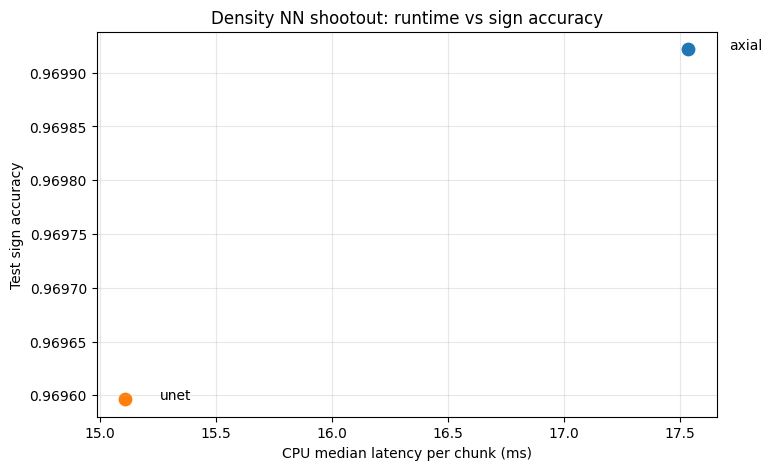

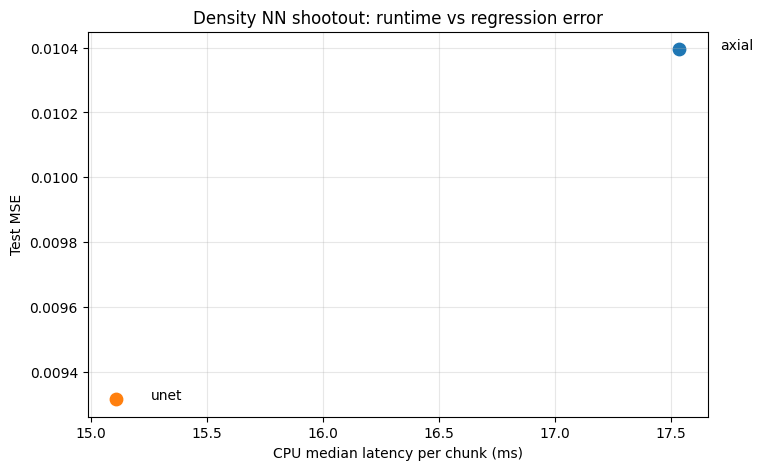

In [23]:
summary_rows = []
for row in results:
    summary_rows.append({
        'id': row['id'],
        'label': row['label'],
        'params': row['params'],
        'test_mse': row['test_mse'],
        'test_sign_acc': row['test_sign_acc'],
        'test_boundary_sign_acc': row['test_boundary_sign_acc'],
        'cpu_median_ms': row['cpu_median_ms'],
        'cpu_chunks_per_s': row['cpu_chunks_per_s'],
    })

summary_rows = sorted(summary_rows, key=lambda r: (-r['test_sign_acc'], r['cpu_median_ms']))

if pd is not None:
    df = pd.DataFrame(summary_rows)
    display(df)
else:
    for row in summary_rows:
        print(row)

plt.figure(figsize=(8, 5))
for row in summary_rows:
    plt.scatter(row['cpu_median_ms'], row['test_sign_acc'], s=80)
    plt.text(row['cpu_median_ms'] * 1.01, row['test_sign_acc'], row['id'])
plt.xlabel('CPU median latency per chunk (ms)')
plt.ylabel('Test sign accuracy')
plt.title('Density NN shootout: runtime vs sign accuracy')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
for row in summary_rows:
    plt.scatter(row['cpu_median_ms'], row['test_mse'], s=80)
    plt.text(row['cpu_median_ms'] * 1.01, row['test_mse'], row['id'])
plt.xlabel('CPU median latency per chunk (ms)')
plt.ylabel('Test MSE')
plt.title('Density NN shootout: runtime vs regression error')
plt.grid(alpha=0.3)
plt.show()

## Training Curves

Use this to inspect whether a model is still improving and whether a slower-but-more-accurate teacher should be distilled into a faster student.

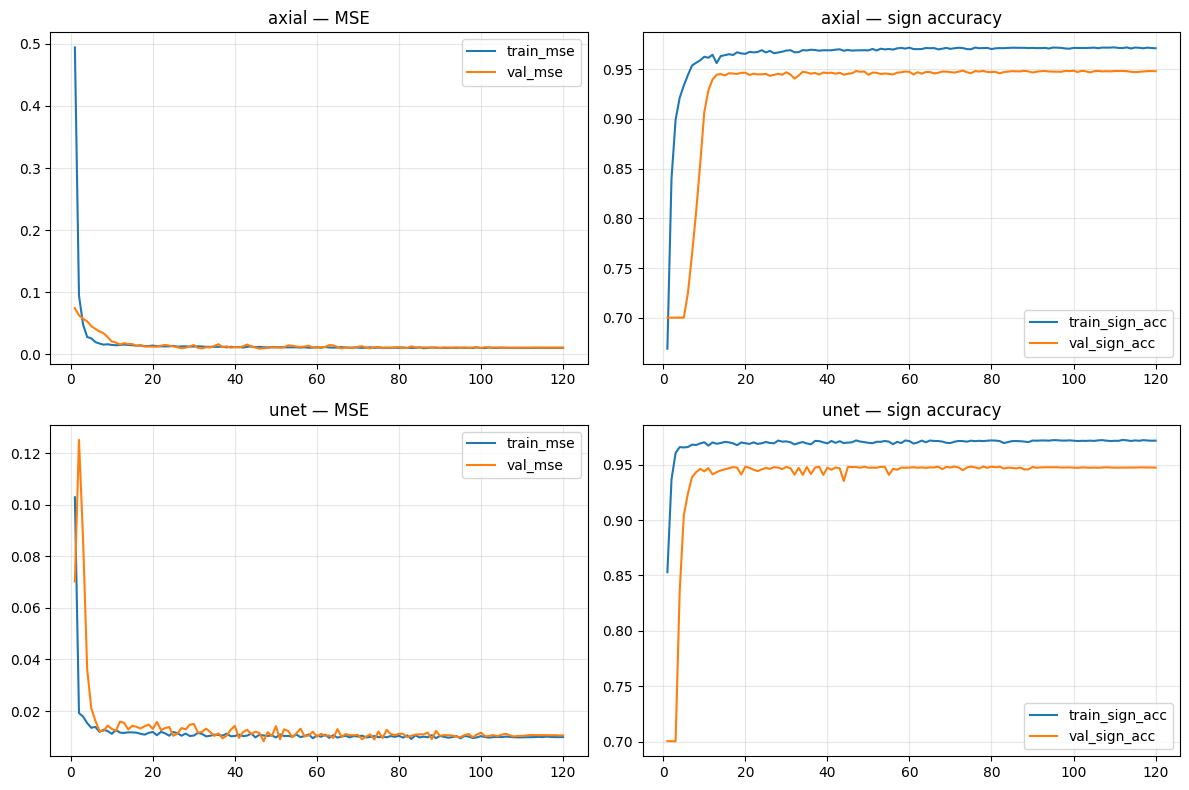

In [24]:
fig, axes = plt.subplots(len(results), 2, figsize=(12, 4 * max(len(results), 1)))
if len(results) == 1:
    axes = np.array([axes])

for r, row in enumerate(results):
    hist = row['history']
    epochs = [h['epoch'] for h in hist]
    axes[r, 0].plot(epochs, [h['train_mse'] for h in hist], label='train_mse')
    axes[r, 0].plot(epochs, [h['val_mse'] for h in hist], label='val_mse')
    axes[r, 0].set_title(f"{row['id']} — MSE")
    axes[r, 0].legend()
    axes[r, 0].grid(alpha=0.3)

    axes[r, 1].plot(epochs, [h['train_sign_acc'] for h in hist], label='train_sign_acc')
    axes[r, 1].plot(epochs, [h['val_sign_acc'] for h in hist], label='val_sign_acc')
    axes[r, 1].set_title(f"{row['id']} — sign accuracy")
    axes[r, 1].legend()
    axes[r, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recommended Next Moves

If you want the **best runtime-deployment path**, the likely sequence is:
1. train `UNET` or `AXIAL` much longer until it nearly saturates
2. distill that teacher into `SEP` or `MLP`
3. re-benchmark CPU latency and boundary sign accuracy
4. export the best fast candidate to ONNX / TorchScript

The architecture that wins this notebook may not be the final deployment winner. Often the best final stack is:
- **slow accurate teacher** for supervision
- **fast separable student** for runtime

## Distillation (teacher → student)

This section trains a **fast student** using a **slower, more accurate teacher**. The student is trained with a mix of:
- ground-truth regression loss (MSE)
- distillation loss (MSE to teacher predictions)
- sign classification loss (same as the main training loop)

The goal is to recover most of the teacher's accuracy while keeping runtime latency low.

In [25]:
# Helpers for distillation

def load_best_model(name: str, device: torch.device):
    path = ARTIFACT_DIR / f'{name}_best.pt'
    if not path.exists():
        raise FileNotFoundError(
            f"Teacher checkpoint not found: {path}\n"
            "Run the main shootout first (so the teacher is trained and checkpointed), "
            "or manually call `train_candidate('{name}', CANDIDATES['{name}'])` to create it."
        )

    model = CANDIDATES[name]['build']().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


def distill_student(teacher_name: str, student_name: str, epochs: int = 120, alpha: float = 0.5, lr: float = LR) -> dict:
    teacher = load_best_model(teacher_name, DEVICE)
    student = CANDIDATES[student_name]['build']().to(DEVICE)
    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))

    history = []
    best_val = math.inf
    best_state = None

    for epoch in range(epochs):
        student.train()
        train_loss = 0.0
        train_mse = 0.0
        train_sign = 0.0
        batches = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            with torch.no_grad():
                teacher_pred = teacher(xb)

            pred = student(xb)
            mse_gt = F.mse_loss(pred, yb)
            mse_teacher = F.mse_loss(pred, teacher_pred)
            sign_target = (yb > 0).float()
            sign_loss = F.binary_cross_entropy_with_logits(pred * 8.0, sign_target)

            loss = alpha * mse_gt + (1 - alpha) * mse_teacher + SIGN_LOSS_WEIGHT * sign_loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            train_loss += float(loss.detach())
            train_mse += float(mse_gt.detach())
            train_sign += (((pred > 0) == (yb > 0)).float().mean().item())
            batches += 1

        scheduler.step()
        val_metrics = evaluate_model(student, val_loader, DEVICE)

        row = {
            'epoch': epoch + 1,
            'train_loss': train_loss / max(batches, 1),
            'train_mse': train_mse / max(batches, 1),
            'train_sign_acc': train_sign / max(batches, 1),
            **{f'val_{k}': v for k, v in val_metrics.items()},
        }
        history.append(row)

        if row['val_mse'] < best_val:
            best_val = row['val_mse']
            best_state = copy.deepcopy(student.state_dict())

        print(
            f"[distill {student_name}<-{teacher_name}] epoch {epoch+1:03d}/{epochs} | "
            f"train_mse={row['train_mse']:.5f} | val_mse={row['val_mse']:.5f} | val_sign={row['val_sign_acc']:.4f}"
        )

    student.load_state_dict(best_state)

    val_best = evaluate_model(student, val_loader, DEVICE)
    test_metrics = evaluate_model(student, test_loader, DEVICE)

    sample = X_test[:1]
    cpu_bench = benchmark_latency_ms(student, sample, CPU_DEVICE)
    active_bench = benchmark_latency_ms(student, sample, DEVICE) if RUN_ACTIVE_DEVICE_BENCH else None

    ckpt_path = ARTIFACT_DIR / f'distill_{student_name}_from_{teacher_name}.pt'
    torch.save(best_state, ckpt_path)

    result = {
        'teacher': teacher_name,
        'student': student_name,
        'alpha': alpha,
        'epochs': epochs,
        'checkpoint_path': str(ckpt_path),
        'best_val_mse': val_best['mse'],
        'best_val_sign_acc': val_best['sign_acc'],
        'best_val_boundary_sign_acc': val_best['boundary_sign_acc'],
        'test_mse': test_metrics['mse'],
        'test_mae': test_metrics['mae'],
        'test_sign_acc': test_metrics['sign_acc'],
        'test_boundary_sign_acc': test_metrics['boundary_sign_acc'],
        'cpu_median_ms': cpu_bench['median_ms'],
        'cpu_p90_ms': cpu_bench['p90_ms'],
        'cpu_chunks_per_s': cpu_bench['chunks_per_s'],
        'active_device_median_ms': None if active_bench is None else active_bench['median_ms'],
        'history': history,
    }

    with open(ARTIFACT_DIR / f'distill_{student_name}_from_{teacher_name}.json', 'w', encoding='utf-8') as fh:
        json.dump(result, fh, indent=2)

    return result


In [26]:
# Run distillation (adjust as desired)
DISTILL_EPOCHS = 120
DISTILL_ALPHA = 0.5
DISTILL_TEACHER = 'unet'
DISTILL_STUDENT = 'sep'

print('Distilling', DISTILL_STUDENT, 'from', DISTILL_TEACHER)
distill_result = distill_student(DISTILL_TEACHER, DISTILL_STUDENT, epochs=DISTILL_EPOCHS, alpha=DISTILL_ALPHA)

if pd is not None:
    display(pd.DataFrame([distill_result]))
else:
    print(distill_result)

Distilling sep from unet
[distill sep<-unet] epoch 001/120 | train_mse=0.24406 | val_mse=0.05487 | val_sign=0.7003
[distill sep<-unet] epoch 002/120 | train_mse=0.06071 | val_mse=0.05469 | val_sign=0.7003
[distill sep<-unet] epoch 003/120 | train_mse=0.03616 | val_mse=0.05218 | val_sign=0.7003
[distill sep<-unet] epoch 004/120 | train_mse=0.02599 | val_mse=0.05233 | val_sign=0.7003
[distill sep<-unet] epoch 005/120 | train_mse=0.02242 | val_mse=0.05511 | val_sign=0.7003
[distill sep<-unet] epoch 006/120 | train_mse=0.01910 | val_mse=0.05526 | val_sign=0.7668
[distill sep<-unet] epoch 007/120 | train_mse=0.01829 | val_mse=0.05208 | val_sign=0.8210
[distill sep<-unet] epoch 008/120 | train_mse=0.01798 | val_mse=0.04305 | val_sign=0.8843
[distill sep<-unet] epoch 009/120 | train_mse=0.01689 | val_mse=0.03289 | val_sign=0.9126
[distill sep<-unet] epoch 010/120 | train_mse=0.01702 | val_mse=0.02237 | val_sign=0.9327
[distill sep<-unet] epoch 011/120 | train_mse=0.01683 | val_mse=0.01747 | v

,teacher,student,alpha,epochs,checkpoint_path,best_val_mse,best_val_sign_acc,best_val_boundary_sign_acc,test_mse,test_mae,test_sign_acc,test_boundary_sign_acc,cpu_median_ms,cpu_p90_ms,cpu_chunks_per_s,active_device_median_ms,history
0,unet,sep,0.5,120,c:\Users\JeffHall\git\MC\VoxelTree\notebooks\e...,0.012892,0.947998,0.871274,0.014504,0.093858,0.97238,0.930618,21.84375,44.53008,45.779685,None,"[{'epoch': 1, 'train_loss': 0.3790050127676555..."
